# Analiza vibracij z rolling shutter kamero

In [126]:
import numpy as np
import matplotlib.pyplot as plt

In [127]:
filename='frames_10fps'

In [128]:
frames = np.load(f'python outputi/{filename}.npy')
timestamps = np.load('python outputi/timestamps_10fps.npy')

In [129]:
frames.shape, timestamps.shape

((10, 3040, 4056, 3), (10,))

In [130]:
odrez_l=40
odrez_d=40

In [131]:
shape = frames.shape
if shape[1] < shape[2]:
    a = (shape[2] - shape[1])
    frames = np.rot90(frames, k=1, axes=(1,2))
    frames = frames[:, a:- a, odrez_l:-odrez_d, :]

99.97822222222221
0.004893936787907719
899.804


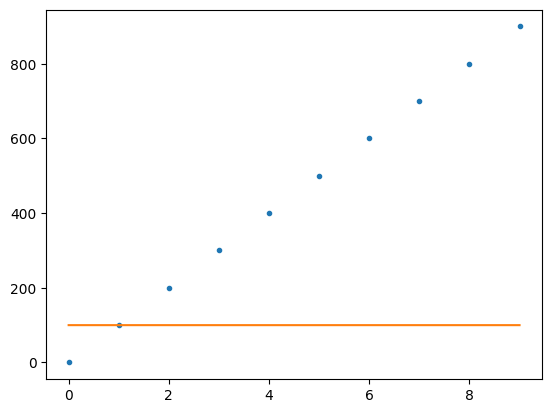

In [132]:
relative_time_ms = (timestamps-timestamps[0])/1e6
plt.plot(relative_time_ms, '.')
plt.plot(np.gradient(relative_time_ms))

diffs_ms = np.diff(relative_time_ms)
print(np.mean(diffs_ms))
print(np.std(diffs_ms))
print((timestamps[-1]-timestamps[0])/1e6)

In [133]:
frames[0,0,0,:]

array([117, 111,  95], dtype=uint8)

In [134]:
frames_gray = (0.299 * frames[:,:,:,0] +   # R
               0.587 * frames[:,:,:,1] +   # G
               0.114 * frames[:,:,:,2]     # B
              ).astype(np.uint8)


#np.save(f"python outputi/{filename}_gray", frames_gray)

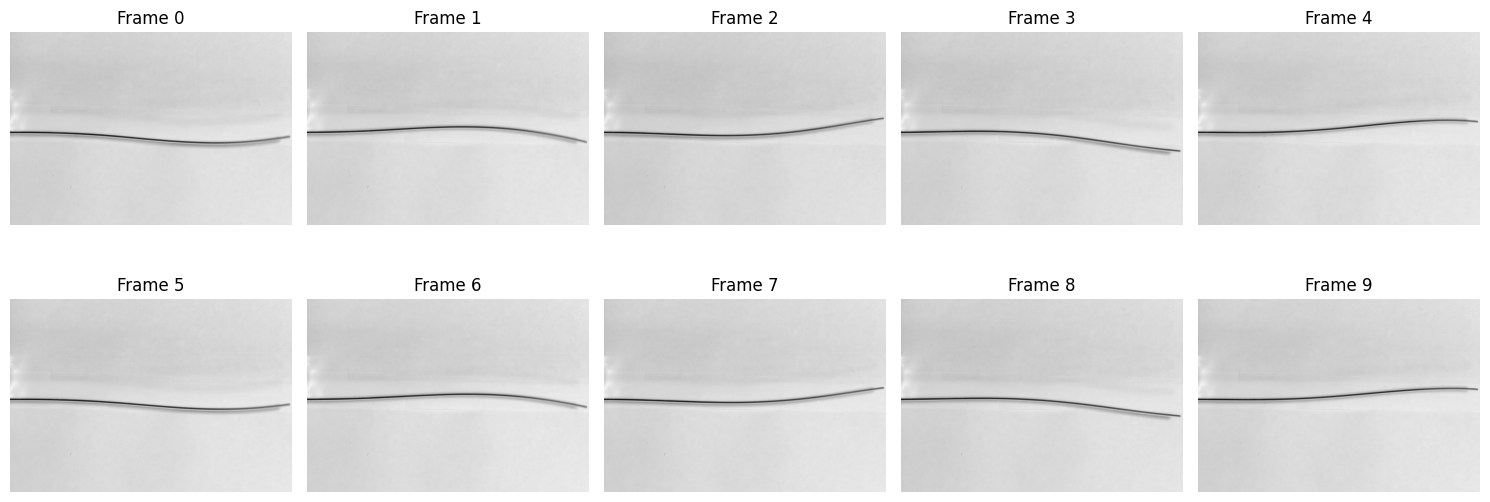

In [135]:
fig, axes = plt.subplots(frames_gray.shape[0]//5, 5, figsize=(15, frames_gray.shape[0]//5*3))
for i, ax in enumerate(axes.flat):
    ax.imshow(frames_gray[i], cmap='gray')
    ax.set_title(f"Frame {i}")
    ax.axis("off")
plt.tight_layout()
plt.show()

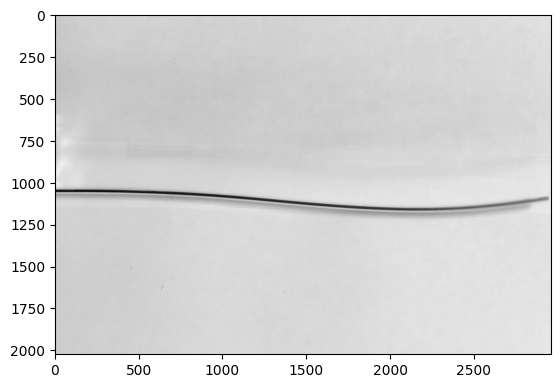

In [136]:
plt.imshow(frames_gray[0], cmap='gray')

In [137]:
#Kakšno frekvenco pričakujemo?
L = 0.3 #m
h = 0.002 #m
E = 2.1 #GPa
rho = 1250 # kg/m^3

frekvenca = 1.875**2*h/(2*np.pi * L**2)*np.sqrt(E*1e9/(12*rho))
print(frekvenca)

4.652369284854503


# Porepoznavanje pomikov:

In [138]:
#for f in disp:
#    plt.plot(f[:,0], label='calc_x')

#plt.legend()

# prepoznavanje probov

In [161]:
import scipy.ndimage as ndimage
def zaznaj_rob(frame):
    frame = ndimage.gaussian_filter(frame, sigma=2)
    grad0 = np.gradient(frame, axis=0)
    rob=[]
    for x in range(frame.shape[-1]-1):
        #y=np.argmin(frame[:,x])
        y=np.argmin(grad0[:,x])
        rob.append([x,y])
    return rob

In [162]:
disp = np.array([zaznaj_rob(frame) for frame in frames_gray])

In [164]:
np.save(f'disp_{filename}', disp)

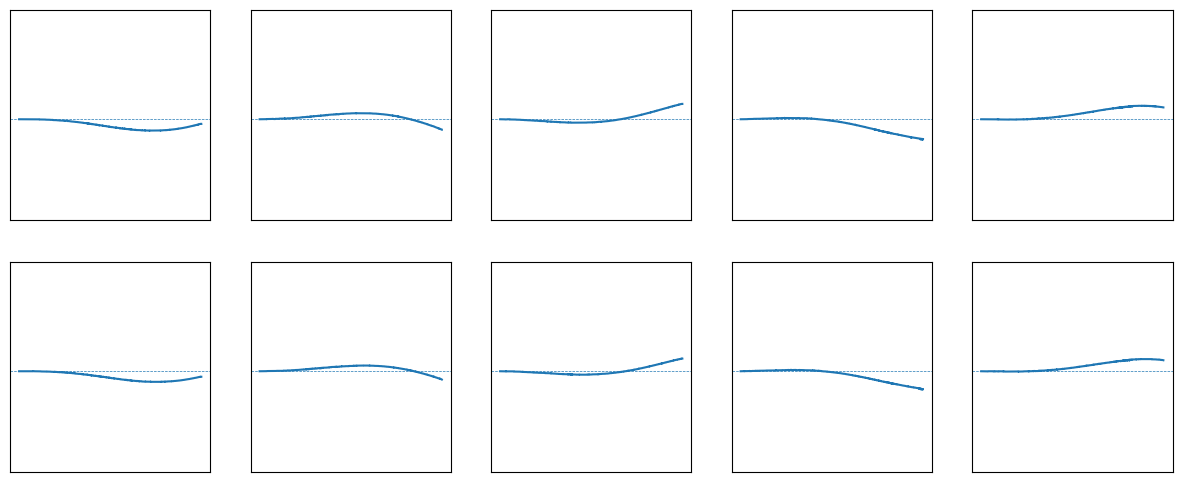

In [159]:
fig, ax = plt.subplots(frames_gray.shape[0]//5, 5, figsize=(15, frames_gray.shape[0]//5*3))
for i, axis in enumerate(ax.flat):    
    axis.plot(disp[i,:-25,1])
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_ylim(frames_gray.shape[1], 0)
    axis.axhline(frames_gray.shape[1]/2+40, linestyle="--", lw=0.5)

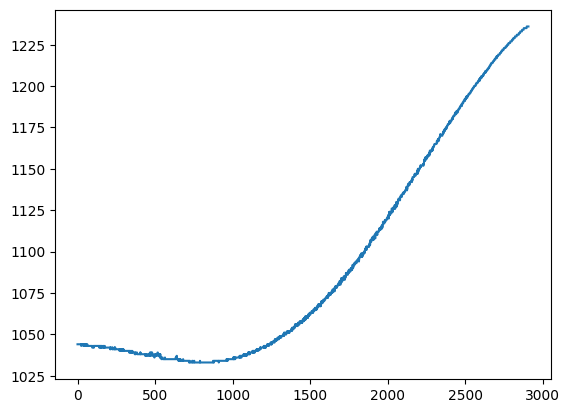

In [163]:
plt.plot(disp[3,:-50,1])